In [ ]:
ontimeperformance = pd.read_csv('MTA_Subway_Terminal_On-Time_Performance__2020-2024_20260226.csv')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
expresslines = ['2', '3', '4', '5', 'A', 'E', 'Q', 'B', 'D', 'N']
locallines = ['1', '6', '7', 'C', 'R', 'W', 'L', 'G', 'M', 'F','JZ']
shuttles = ['MS', 'BS', 'QS', 'FS', 'GS', 'H']
independentlines = ['7', 'L', 'G']
expressontimeperformance = ontimeperformance[ontimeperformance['line'].isin(expresslines)]
localontimeperformance = ontimeperformance[ontimeperformance['line'].isin(locallines)]
shuttleontimeperformance = ontimeperformance[ontimeperformance['line'].isin(shuttles)]
print('Local lines:', locallines, 'Express lines: ', expresslines, 'Shuttles: ', shuttles, 'day types: 1 for weekday, 2 for weekend')

Text(0, 0.5, 'OTP')

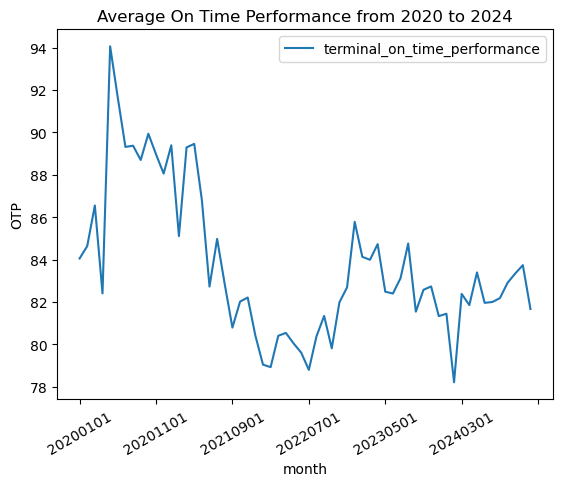

In [12]:
import pandas as pd
import numpy as np
import matplotlib 
import matplotlib.pyplot as plt

ontimeperformance = pd.read_csv('MTA_Subway_Terminal_On-Time_Performance__2020-2024_20260226.csv')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

ontimeperformance['month'] = ontimeperformance['month'].astype(str)
ontimeperformance['line'] = ontimeperformance['line'].astype(str)

monthlyaverage= ontimeperformance.groupby(['month'])['terminal_on_time_performance'].mean().reset_index()

monthlyaverage.plot.line(x = 'month', y = 'terminal_on_time_performance', title = 'Average On Time Performance from 2020 to 2024')

plt.xticks(rotation = 30, horizontalalignment = 'center') 
plt.xlabel('month')
plt.ylabel('OTP')

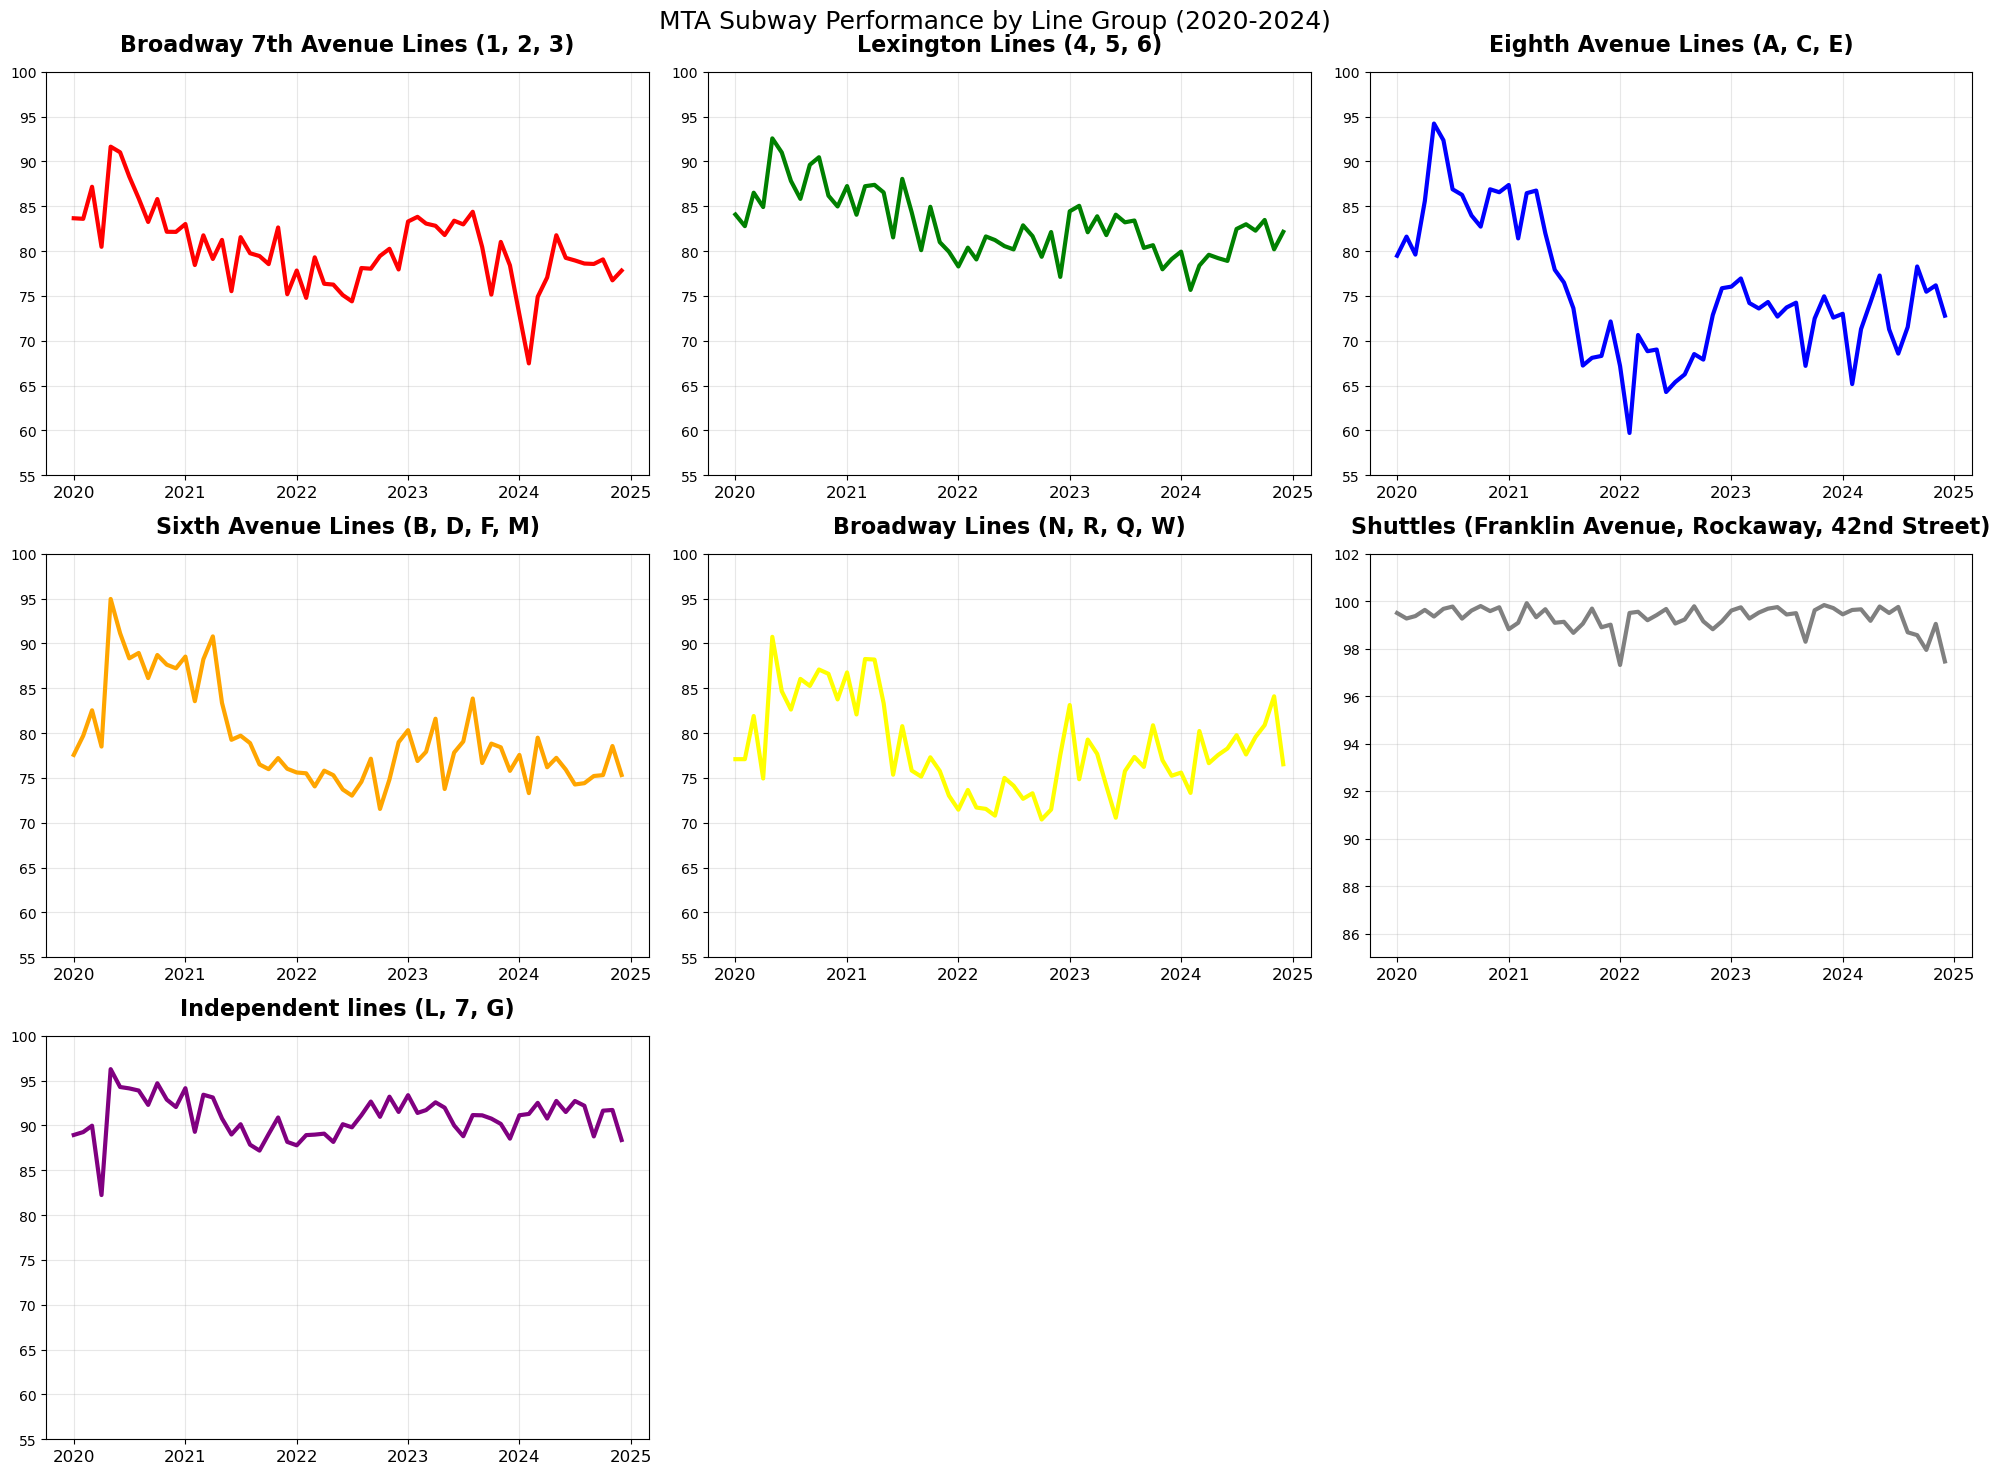

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ontimeperformance = pd.read_csv('MTA_Subway_Terminal_On-Time_Performance__2020-2024_20260226.csv')
ontimeperformance['month'] = pd.to_datetime(df['month'].astype(str), format='mixed')

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 15))
axes_list = axes.flatten()

for j in range(len(box_configs), len(axes_list)):
    axes_list[j].axis('off')

for i, config in enumerate(box_configs):
    
    data = ontimeperformance[ontimeperformance['line'].isin(config['lines'])].groupby('month')['terminal_on_time_performance'].mean()
    

    axes_list[i].plot(data.index, data.values, color=config['color'], linewidth=3)
    
    axes_list[i].set_title(config['title'], fontsize=16, fontweight='bold', pad=15)
    
    axes_list[i].set_ylim(55, 100) 
    axes_list[i].grid(True, alpha=0.3)
    

    axes_list[i].xaxis.set_major_locator(mdates.YearLocator())
    axes_list[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(axes_list[i].get_xticklabels(), rotation=0, fontsize=12)

    if 'Shuttles' in config['title']:
        axes_list[i].set_ylim(85, 102) 
    else:
        axes_list[i].set_ylim(55, 100)


for j in range(len(box_configs), len(axes_list)):
    axes_list[j].axis('off')

box_configs = [
    {'title': 'Broadway 7th Avenue Lines (1, 2, 3)', 'lines': ['1', '2', '3'], 'color': 'red'},
    {'title': 'Lexington Lines (4, 5, 6)', 'lines': ['4', '5', '6'], 'color': 'green'},
    {'title': 'Eighth Avenue Lines (A, C, E)', 'lines': ['A', 'C', 'E'], 'color': 'blue'},
    {'title': 'Sixth Avenue Lines (B, D, F, M)', 'lines': ['B', 'D', 'F', 'M'], 'color': 'orange'},
    {'title': 'Broadway Lines (N, R, Q, W)', 'lines': ['N', 'R', 'Q', 'W'], 'color':'yellow'},
    {'title': 'Shuttles (Franklin Avenue, Rockaway, 42nd Street)', 'lines': ['MS', 'QS', 'BS', 'FS', 'GS'], 'color':'grey'},
    {'title': 'Independent lines (L, 7, G)', 'lines':['L', '7', 'G'], 'color': 'purple'}
]


plt.suptitle('MTA Subway Performance by Line Group (2020-2024)', fontsize=18, y=0.98)
plt.tight_layout()
plt.show()


In [3]:
import pandas as pd

ontimeperformance = pd.read_csv('MTA_Subway_Terminal_On-Time_Performance__2020-2024_20260226.csv')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

ontimeperformance['month'] = ontimeperformance['month'].astype(str)
ontimeperformance['line'] = ontimeperformance['line'].astype(str)

expresslines = ['2', '3', '4', '5', 'A', 'E', 'Q', 'B', 'D', 'N']
adivisionlines =['2', '3', '4', '5']
bdivisionlines = ['A', 'B','D', 'E', 'N', 'Q']

adivisionexpressweekdayontimeperformance2020belowseventyfive = ontimeperformance[
    (ontimeperformance['line'].isin(adivisionlines)) & 
    (ontimeperformance['day_type']==1) &
    (ontimeperformance['terminal_on_time_performance']<=75)
]

adivisionexpressweekendontimeperformance2020belowseventyfive = ontimeperformance[
    (ontimeperformance['line'].isin(adivisionlines)) & 
    (ontimeperformance['day_type']==2) &
   (ontimeperformance['terminal_on_time_performance']<=75)
]
adivisionweekday = adivisionexpressweekdayontimeperformance2020belowseventyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()
adivisionweekend = adivisionexpressweekendontimeperformance2020belowseventyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()

bdivisionexpressweekdayontimeperformance2020belowseventyfive = ontimeperformance[
    (ontimeperformance['line'].isin(bdivisionlines)) & 
    (ontimeperformance['day_type']==1) &
    (ontimeperformance['terminal_on_time_performance']<=75)
]

bdivisionexpressweekendontimeperformance2020belowseventyfive = ontimeperformance[
    (ontimeperformance['line'].isin(bdivisionlines)) & 
    (ontimeperformance['day_type']==2) &
    (ontimeperformance['terminal_on_time_performance']<=75)
]
bdivisionweekday = bdivisionexpressweekdayontimeperformance2020belowseventyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()
bdivisionweekend = bdivisionexpressweekendontimeperformance2020belowseventyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()

sortedadivisionweekday = adivisionweekday.sort_values(by='terminal_on_time_performance', ascending=False)
sortedadivisionweekend = adivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekday = bdivisionweekday.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekend = bdivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)

bestperformingweekdayAlinesbelowseventyfive = sortedadivisionweekday.head(5).reset_index(drop=True)
worstperformingweekdayAlinesbelowseventyfive = sortedadivisionweekday.tail(5).reset_index(drop=True)
bestperformingweekdayBlinesbelowseventyfive = sortedbdivisionweekday.head(5).reset_index(drop=True)
worstperformingweekdayBlinesbelowseventyfive = sortedbdivisionweekday.tail(5).reset_index(drop=True)

bestperformingweekendAlinesbelowseventyfive = sortedadivisionweekend.head(5).reset_index(drop=True)
worstperformingweekendAlinesbelowseventyfive = sortedadivisionweekend.tail(5).reset_index(drop=True)
bestperformingweekendBlinesbelowseventyfive = sortedbdivisionweekend.head(5).reset_index(drop=True)
worstperformingweekendBlinesbelowseventyfive = sortedbdivisionweekend.tail(5).reset_index(drop=True)

print(bestperformingweekdayAlinesbelowseventyfive)
print(worstperformingweekdayAlinesbelowseventyfive)
print(bestperformingweekdayBlinesbelowseventyfive)
print(worstperformingweekdayBlinesbelowseventyfive)
print (bestperformingweekendAlinesbelowseventyfive)
print (worstperformingweekendAlinesbelowseventyfive)
print (bestperformingweekendBlinesbelowseventyfive)
print (worstperformingweekendBlinesbelowseventyfive)

      month  day_type line  terminal_on_time_performance
0  20240701         1    2                     74.934655
1  20220201         1    2                     74.865960
2  20211201         1    2                     74.286930
3  20221101         1    2                     74.014940
4  20210201         1    2                     73.912334
      month  day_type line  terminal_on_time_performance
0  20240101         1    2                     69.905144
1  20231201         1    2                     69.596670
2  20231001         1    2                     68.564254
3  20220901         1    2                     68.094470
4  20241201         1    2                     67.071605
      month  day_type line  terminal_on_time_performance
0  20230701         1    E                     74.975610
1  20230301         1    E                     74.968140
2  20210701         1    Q                     74.967350
3  20230601         1    A                     74.948615
4  20240501         1    A     

In [4]:
import pandas as pd

ontimeperformance = pd.read_csv('MTA_Subway_Terminal_On-Time_Performance__2020-2024_20260226.csv')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

ontimeperformance['month'] = ontimeperformance['month'].astype(str)
ontimeperformance['line'] = ontimeperformance['line'].astype(str)

expresslines = ['2', '3', '4', '5', 'A', 'E', 'Q', 'B', 'D', 'N']
adivisionlines =['2', '3', '4', '5']
bdivisionlines = ['A', 'B','D', 'E', 'N', 'Q']

adivisionexpressweekdayontimeperformance2020seventyfivetoeighty = ontimeperformance[
    (ontimeperformance['line'].isin(adivisionlines)) & 
    (ontimeperformance['day_type']==1) &
    (ontimeperformance['terminal_on_time_performance']>=75)&
    (ontimeperformance['terminal_on_time_performance']<=80)
]

adivisionexpressweekendontimeperformance2020seventyfivetoeighty = ontimeperformance[
    (ontimeperformance['line'].isin(adivisionlines)) & 
    (ontimeperformance['day_type']==2) &
    (ontimeperformance['terminal_on_time_performance']>=75)&
    (ontimeperformance['terminal_on_time_performance']<=80)
]
adivisionweekday = adivisionexpressweekdayontimeperformance2020seventyfivetoeighty.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()
adivisionweekend = adivisionexpressweekendontimeperformance2020seventyfivetoeighty.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()

bdivisionexpressweekdayontimeperformance2020seventyfivetoeighty = ontimeperformance[
    (ontimeperformance['line'].isin(bdivisionlines)) & 
    (ontimeperformance['day_type']==1) &
    (ontimeperformance['terminal_on_time_performance']>=75)&
    (ontimeperformance['terminal_on_time_performance']<=80)
]

bdivisionexpressweekendontimeperformance2020seventyfivetoeighty = ontimeperformance[
    (ontimeperformance['line'].isin(bdivisionlines)) & 
    (ontimeperformance['day_type']==2) &
    (ontimeperformance['terminal_on_time_performance']>=75)&
    (ontimeperformance['terminal_on_time_performance']<=80)
]
bdivisionweekday = bdivisionexpressweekdayontimeperformance2020seventyfivetoeighty.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()
bdivisionweekend = bdivisionexpressweekendontimeperformance2020seventyfivetoeighty.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()

sortedadivisionweekday = adivisionweekday.sort_values(by='terminal_on_time_performance', ascending=False)
sortedadivisionweekend = adivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekday = bdivisionweekday.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekend = bdivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)

bestperformingweekdayAlinesseventyfivetoeighty = sortedadivisionweekday.head(5).reset_index(drop=True)
worstperformingweekdayAlinesseventyfivetoeighty = sortedadivisionweekday.tail(5).reset_index(drop=True)
bestperformingweekdayBlinesseventyfivetoeighty = sortedbdivisionweekday.head(5).reset_index(drop=True)
worstperformingweekdayBlinesseventyfivetoeighty = sortedbdivisionweekday.tail(5).reset_index(drop=True)


sortedadivisionweekend = adivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekend = bdivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)

bestperformingweekendAlinesseventyfivetoeighty = sortedadivisionweekend.head(5).reset_index(drop=True)
worstperformingweekendAlinesseventyfivetoeighty = sortedadivisionweekend.tail(5).reset_index(drop=True)
bestperformingweekendBlinesseventyfivetoeighty = sortedbdivisionweekend.head(5).reset_index(drop=True)
worstperformingweekendBlinesseventyfivetoeighty = sortedbdivisionweekend.tail(5).reset_index(drop=True)

print(bestperformingweekdayAlinesseventyfivetoeighty)
print(worstperformingweekdayAlinesseventyfivetoeighty)
print(bestperformingweekdayBlinesseventyfivetoeighty)
print(worstperformingweekdayBlinesseventyfivetoeighty)
print (bestperformingweekendAlinesseventyfivetoeighty)
print (worstperformingweekendAlinesseventyfivetoeighty)
print (bestperformingweekendBlinesseventyfivetoeighty)
print (worstperformingweekendBlinesseventyfivetoeighty)

      month  day_type line  terminal_on_time_performance
0  20210301         1    2                     79.954034
1  20240301         1    4                     79.912436
2  20230901         1    4                     79.840450
3  20240901         1    5                     79.578480
4  20230101         1    2                     79.503745
      month  day_type line  terminal_on_time_performance
0  20220901         1    5                     75.954926
1  20230301         1    2                     75.613660
2  20221001         1    5                     75.581910
3  20230501         1    2                     75.187550
4  20241001         1    2                     75.103790
      month  day_type line  terminal_on_time_performance
0  20240701         1    Q                     79.975800
1  20241101         1    N                     79.709990
2  20201201         1    N                     79.392296
3  20240801         1    E                     79.379160
4  20241201         1    A     

In [4]:
import pandas as pd

ontimeperformance = pd.read_csv('MTA_Subway_Terminal_On-Time_Performance__2020-2024_20260226.csv')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

ontimeperformance['month'] = ontimeperformance['month'].astype(str)
ontimeperformance['line'] = ontimeperformance['line'].astype(str)

expresslines = ['2', '3', '4', '5', 'A', 'E', 'Q', 'B', 'D', 'N']
adivisionlines =['2', '3', '4', '5']
bdivisionlines = ['A', 'B','D', 'E', 'N', 'Q']

adivisionexpressweekdayontimeperformance2020eightytoeightyfive = ontimeperformance[
    (ontimeperformance['line'].isin(adivisionlines)) & 
    (ontimeperformance['day_type']==1) &
    (ontimeperformance['terminal_on_time_performance']>=80)&
    (ontimeperformance['terminal_on_time_performance']<=85)
]

adivisionexpressweekendontimeperformance2020eightytoeightyfive = ontimeperformance[
    (ontimeperformance['line'].isin(adivisionlines)) & 
    (ontimeperformance['day_type']==2) &
    (ontimeperformance['terminal_on_time_performance']>=80)&
    (ontimeperformance['terminal_on_time_performance']<=85)
]
adivisionweekday = adivisionexpressweekdayontimeperformance2020eightytoeightyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()
adivisionweekend = adivisionexpressweekendontimeperformance2020eightytoeightyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()

bdivisionexpressweekdayontimeperformance2020eightytoeightyfive = ontimeperformance[
    (ontimeperformance['line'].isin(bdivisionlines)) & 
    (ontimeperformance['day_type']==1) &
    (ontimeperformance['terminal_on_time_performance']>=80)&
    (ontimeperformance['terminal_on_time_performance']<=85)
]

bdivisionexpressweekendontimeperformance2020eightytoeightyfive = ontimeperformance[
    (ontimeperformance['line'].isin(bdivisionlines)) & 
    (ontimeperformance['day_type']==2) &
    (ontimeperformance['terminal_on_time_performance']>=80)&
    (ontimeperformance['terminal_on_time_performance']<=85)
]
bdivisionweekday = bdivisionexpressweekdayontimeperformance2020eightytoeightyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()
bdivisionweekend = bdivisionexpressweekendontimeperformance2020eightytoeightyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()

sortedadivisionweekday = adivisionweekday.sort_values(by='terminal_on_time_performance', ascending=False)
sortedadivisionweekend = adivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekday = bdivisionweekday.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekend = bdivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)

bestperformingweekdayAlineseightytoeightyfive = sortedadivisionweekday.head(5).reset_index(drop=True)
worstperformingweekdayAlineseightytoeightyfive = sortedadivisionweekday.tail(5).reset_index(drop=True)
bestperformingweekdayBlineseightytoeightyfive = sortedbdivisionweekday.head(5).reset_index(drop=True)
worstperformingweekdayBlineseightytoeightyfive = sortedbdivisionweekday.tail(5).reset_index(drop=True)


sortedadivisionweekend = adivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekend = bdivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)

bestperformingweekendAlineseightytoeightyfive = sortedadivisionweekend.head(5).reset_index(drop=True)
worstperformingweekendAlineseightytoeightyfive = sortedadivisionweekend.tail(5).reset_index(drop=True)
bestperformingweekendBlineseightytoeightyfive = sortedbdivisionweekend.head(5).reset_index(drop=True)
worstperformingweekendBlineseightytoeightyfive = sortedbdivisionweekend.tail(5).reset_index(drop=True)

print(bestperformingweekdayAlineseightytoeightyfive)
print(worstperformingweekdayAlineseightytoeightyfive)
print(bestperformingweekdayBlineseightytoeightyfive)
print(worstperformingweekdayBlineseightytoeightyfive)
print (bestperformingweekendAlineseightytoeightyfive)
print (worstperformingweekendAlineseightytoeightyfive)
print (bestperformingweekendBlineseightytoeightyfive)
print (worstperformingweekendBlineseightytoeightyfive)

      month  day_type line  terminal_on_time_performance
0  20210801         1    4                     84.965074
1  20240801         1    3                     84.964350
2  20210701         1    3                     84.942900
3  20200701         1    2                     84.872407
4  20210701         1    4                     84.818440
      month  day_type line  terminal_on_time_performance
0  20220201         1    5                     80.516356
1  20210201         1    5                     80.285530
2  20220301         1    2                     80.215450
3  20231201         1    5                     80.151975
4  20211201         1    4                     80.088663
      month  day_type line  terminal_on_time_performance
0  20200801         1    D                     84.984356
1  20200101         1    Q                     84.717800
2  20200901         1    B                     84.549880
3  20200701         1    D                     84.455870
4  20210301         1    N     

In [5]:
import pandas as pd

ontimeperformance = pd.read_csv('MTA_Subway_Terminal_On-Time_Performance__2020-2024_20260226.csv')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

ontimeperformance['month'] = ontimeperformance['month'].astype(str)
ontimeperformance['line'] = ontimeperformance['line'].astype(str)

expresslines = ['2', '3', '4', '5', 'A', 'E', 'Q', 'B', 'D', 'N']
adivisionlines =['2', '3', '4', '5']
bdivisionlines = ['A', 'B','D', 'E', 'N', 'Q']

adivisionexpressweekdayontimeperformance2020eightyfivetoninety = ontimeperformance[
    (ontimeperformance['line'].isin(adivisionlines)) & 
    (ontimeperformance['day_type']==1) &
    (ontimeperformance['terminal_on_time_performance']>=85)&
    (ontimeperformance['terminal_on_time_performance']<=90)
]

adivisionexpressweekendontimeperformance2020eightyfivetoninety = ontimeperformance[
    (ontimeperformance['line'].isin(adivisionlines)) & 
    (ontimeperformance['day_type']==2) &
    (ontimeperformance['terminal_on_time_performance']>=85)&
    (ontimeperformance['terminal_on_time_performance']<=90)
]
adivisionweekday = adivisionexpressweekdayontimeperformance2020eightyfivetoninety.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()
adivisionweekend = adivisionexpressweekendontimeperformance2020eightyfivetoninety.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()

bdivisionexpressweekdayontimeperformance2020eightyfivetoninety = ontimeperformance[
    (ontimeperformance['line'].isin(bdivisionlines)) & 
    (ontimeperformance['day_type']==1) &
    (ontimeperformance['terminal_on_time_performance']>=85)&
    (ontimeperformance['terminal_on_time_performance']<=90)
]

bdivisionexpressweekendontimeperformance2020eightyfivetoninety = ontimeperformance[
    (ontimeperformance['line'].isin(bdivisionlines)) & 
    (ontimeperformance['day_type']==2) &
    (ontimeperformance['terminal_on_time_performance']>=85)&
    (ontimeperformance['terminal_on_time_performance']<=90)
]
bdivisionweekday = bdivisionexpressweekdayontimeperformance2020eightyfivetoninety.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()
bdivisionweekend = bdivisionexpressweekendontimeperformance2020eightyfivetoninety.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()

sortedadivisionweekday = adivisionweekday.sort_values(by='terminal_on_time_performance', ascending=False)
sortedadivisionweekend = adivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekday = bdivisionweekday.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekend = bdivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)

bestperformingweekdayAlineseightyfivetoninety = sortedadivisionweekday.head(5).reset_index(drop=True)
worstperformingweekdayAlineseightyfivetoninety = sortedadivisionweekday.tail(5).reset_index(drop=True)
bestperformingweekdayBlineseightyfivetoninety = sortedbdivisionweekday.head(5).reset_index(drop=True)
worstperformingweekdayBlineseightyfivetoninety = sortedbdivisionweekday.tail(5).reset_index(drop=True)


sortedadivisionweekend = adivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekend = bdivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)

bestperformingweekendAlineseightyfivetoninety = sortedadivisionweekend.head(5).reset_index(drop=True)
worstperformingweekendAlineseightyfivetoninety = sortedadivisionweekend.tail(5).reset_index(drop=True)
bestperformingweekendBlineseightyfivetoninety = sortedbdivisionweekend.head(5).reset_index(drop=True)
worstperformingweekendBlineseightyfivetoninety = sortedbdivisionweekend.tail(5).reset_index(drop=True)

print(bestperformingweekdayAlineseightyfivetoninety)
print(worstperformingweekdayAlineseightyfivetoninety)
print(bestperformingweekdayBlineseightyfivetoninety)
print(worstperformingweekdayBlineseightyfivetoninety)
print (bestperformingweekendAlineseightyfivetoninety)
print (worstperformingweekendAlineseightyfivetoninety)
print (bestperformingweekendBlineseightyfivetoninety)
print (worstperformingweekendBlineseightyfivetoninety)

      month  day_type line  terminal_on_time_performance
0  20201001         1    5                     89.869190
1  20200501         1    5                     89.849980
2  20230601         1    3                     89.706326
3  20211101         1    3                     89.653546
4  20200601         1    5                     89.586480
      month  day_type line  terminal_on_time_performance
0  20210501         1    2                     85.225170
1  20241001         1    5                     85.102670
2  20200101         1    5                     85.048410
3  20220601         1    5                     85.023487
4  20211201         1    3                     85.014254
      month  day_type line  terminal_on_time_performance
0  20200601         1    D                     89.718400
1  20200601         1    A                     89.413637
2  20200501         1    N                     89.375985
3  20200901         1    Q                     89.214800
4  20200401         1    E     

In [6]:
import pandas as pd

ontimeperformance = pd.read_csv('MTA_Subway_Terminal_On-Time_Performance__2020-2024_20260226.csv')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

ontimeperformance['month'] = ontimeperformance['month'].astype(str)
ontimeperformance['line'] = ontimeperformance['line'].astype(str)

expresslines = ['2', '3', '4', '5', 'A', 'E', 'Q', 'B', 'D', 'N']
adivisionlines =['2', '3', '4', '5']
bdivisionlines = ['A', 'B','D', 'E', 'N', 'Q']

adivisionexpressweekdayontimeperformance2020aboveninety = ontimeperformance[
    (ontimeperformance['line'].isin(adivisionlines)) & 
    (ontimeperformance['day_type']==1) &
    (ontimeperformance['terminal_on_time_performance']>=90)
]

adivisionexpressweekendontimeperformance2020aboveninety = ontimeperformance[
    (ontimeperformance['line'].isin(adivisionlines)) & 
    (ontimeperformance['day_type']==2) &
    (ontimeperformance['terminal_on_time_performance']>=90)
]
adivisionweekday = adivisionexpressweekdayontimeperformance2020aboveninety.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()
adivisionweekend = adivisionexpressweekendontimeperformance2020aboveninety.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()

bdivisionexpressweekdayontimeperformance2020aboveninety = ontimeperformance[
    (ontimeperformance['line'].isin(bdivisionlines)) & 
    (ontimeperformance['day_type']==1) &
    (ontimeperformance['terminal_on_time_performance']>=90)
]

bdivisionexpressweekendontimeperformance2020aboveninety = ontimeperformance[
    (ontimeperformance['line'].isin(bdivisionlines)) & 
    (ontimeperformance['day_type']==2) &
    (ontimeperformance['terminal_on_time_performance']>=90)
]
bdivisionweekday = bdivisionexpressweekdayontimeperformance2020aboveninety.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()
bdivisionweekend = bdivisionexpressweekendontimeperformance2020aboveninety.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()

sortedadivisionweekday = adivisionweekday.sort_values(by='terminal_on_time_performance', ascending=False)
sortedadivisionweekend = adivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekday = bdivisionweekday.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekend = bdivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)

bestperformingweekdayAlinesaboveninety = sortedadivisionweekday.head(5).reset_index(drop=True)
worstperformingweekdayAlinesaboveninety = sortedadivisionweekday.tail(5).reset_index(drop=True)
bestperformingweekdayBlinesaboveninety = sortedbdivisionweekday.head(5).reset_index(drop=True)
worstperformingweekdayBlinesaboveninety = sortedbdivisionweekday.tail(5).reset_index(drop=True)


sortedadivisionweekend = adivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekend = bdivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)

bestperformingweekendAlinesaboveninety = sortedadivisionweekend.head(5).reset_index(drop=True)
worstperformingweekendAlinesaboveninety = sortedadivisionweekend.tail(5).reset_index(drop=True)
bestperformingweekendBlinesaboveninety = sortedbdivisionweekend.head(5).reset_index(drop=True)
worstperformingweekendBlinesaboveninety = sortedbdivisionweekend.tail(5).reset_index(drop=True)

print(bestperformingweekdayAlinesaboveninety)
print(worstperformingweekdayAlinesaboveninety)
print(bestperformingweekdayBlinesaboveninety)
print(worstperformingweekdayBlinesaboveninety)
print (bestperformingweekendAlinesaboveninety)
print (worstperformingweekendAlinesaboveninety)
print (bestperformingweekendBlinesaboveninety)
print (worstperformingweekendBlinesaboveninety)

      month  day_type line  terminal_on_time_performance
0  20200501         1    4                     94.324327
1  20200501         1    3                     93.667130
2  20200601         1    3                     93.473590
3  20200401         1    4                     92.697203
4  20200501         1    2                     92.546296
      month  day_type line  terminal_on_time_performance
0  20200401         1    5                     90.538100
1  20201001         1    4                     90.495920
2  20200601         1    2                     90.280896
3  20201101         1    3                     90.189505
4  20210501         1    3                     90.180665
      month  day_type line  terminal_on_time_performance
0  20200501         1    E                     96.875000
1  20200501         1    Q                     95.984125
2  20200601         1    E                     94.013330
3  20200501         1    D                     93.960670
4  20200501         1    A     

In [2]:
import pandas as pd

ontimeperformance = pd.read_csv('MTA_Subway_Terminal_On-Time_Performance__2020-2024_20260226.csv')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

ontimeperformance['month'] = ontimeperformance['month'].astype(str)
ontimeperformance['line'] = ontimeperformance['line'].astype(str)

locallines = ['1', '6', '7', 'C', 'R', 'W', 'L', 'G', 'M', 'F','JZ']
adivisionlines =['1', '6', '7']
bdivisionlines = ['C', 'R','W', 'L', 'G', 'M', 'F', 'JZ']

adivisionlocalweekdayontimeperformance2020belowseventyfive = ontimeperformance[
    (ontimeperformance['line'].isin(adivisionlines)) & 
    (ontimeperformance['day_type']==1) &
    (ontimeperformance['terminal_on_time_performance']<=75)
]

adivisionlocalweekendontimeperformance2020belowseventyfive = ontimeperformance[
    (ontimeperformance['line'].isin(adivisionlines)) & 
    (ontimeperformance['day_type']==2) &
   (ontimeperformance['terminal_on_time_performance']<=75)
]
adivisionweekday = adivisionlocalweekdayontimeperformance2020belowseventyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()
adivisionweekend = adivisionlocalweekendontimeperformance2020belowseventyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()

bdivisionlocalweekdayontimeperformance2020belowseventyfive = ontimeperformance[
    (ontimeperformance['line'].isin(bdivisionlines)) & 
    (ontimeperformance['day_type']==1) &
    (ontimeperformance['terminal_on_time_performance']<=75)
]

bdivisionlocalweekendontimeperformance2020belowseventyfive = ontimeperformance[
    (ontimeperformance['line'].isin(bdivisionlines)) & 
    (ontimeperformance['day_type']==2) &
    (ontimeperformance['terminal_on_time_performance']<=75)
]
bdivisionweekday = bdivisionlocalweekdayontimeperformance2020belowseventyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()
bdivisionweekend = bdivisionlocalweekendontimeperformance2020belowseventyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()

sortedadivisionweekday = adivisionweekday.sort_values(by='terminal_on_time_performance', ascending=False)
sortedadivisionweekend = adivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekday = bdivisionweekday.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekend = bdivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)

bestperformingweekdayAlinesbelowseventyfive = sortedadivisionweekday.head(5).reset_index(drop=True)
worstperformingweekdayAlinesbelowseventyfive = sortedadivisionweekday.tail(5).reset_index(drop=True)
bestperformingweekdayBlinesbelowseventyfive = sortedbdivisionweekday.head(5).reset_index(drop=True)
worstperformingweekdayBlinesbelowseventyfive = sortedbdivisionweekday.tail(5).reset_index(drop=True)


sortedadivisionweekend = adivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekend = bdivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)

bestperformingweekendAlinesbelowseventyfive = sortedadivisionweekend.head(5).reset_index(drop=True)
worstperformingweekendAlinesbelowseventyfive = sortedadivisionweekend.tail(5).reset_index(drop=True)
bestperformingweekendBlinesbelowseventyfive = sortedbdivisionweekend.head(5).reset_index(drop=True)
worstperformingweekendBlinesbelowseventyfive = sortedbdivisionweekend.tail(5).reset_index(drop=True)

print(bestperformingweekdayAlinesbelowseventyfive)
print(worstperformingweekdayAlinesbelowseventyfive)
print(bestperformingweekdayBlinesbelowseventyfive)
print(worstperformingweekdayBlinesbelowseventyfive)
print (bestperformingweekendAlinesbelowseventyfive)
print (worstperformingweekendAlinesbelowseventyfive)
print (bestperformingweekendBlinesbelowseventyfive)
print (worstperformingweekendBlinesbelowseventyfive)

      month  day_type line  terminal_on_time_performance
0  20240201         1    6                     73.975480
1  20220101         1    6                     73.865580
2  20231201         1    6                     72.890920
3  20240101         1    1                     72.733855
4  20231101         1    6                     72.482646
      month  day_type line  terminal_on_time_performance
0  20220101         1    6                     73.865580
1  20231201         1    6                     72.890920
2  20240101         1    1                     72.733855
3  20231101         1    6                     72.482646
4  20240301         1    6                     67.826533
      month  day_type line  terminal_on_time_performance
0  20220801         1    R                     74.911660
1  20220901         1    R                     74.894760
2  20230701         1    R                     74.814420
3  20230401         1    F                     74.767070
4  20221101         1    R     

In [6]:
import pandas as pd

ontimeperformance = pd.read_csv('MTA_Subway_Terminal_On-Time_Performance__2020-2024_20260226.csv')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

ontimeperformance['month'] = ontimeperformance['month'].astype(str)
ontimeperformance['line'] = ontimeperformance['line'].astype(str)

locallines = ['1', '6', '7', 'C', 'R', 'W', 'L', 'G', 'M', 'F','JZ']
adivisionlines =['1', '6', '7']
bdivisionlines = ['C', 'R','W', 'L', 'G', 'M', 'F', 'JZ']

adivisionexpressweekdayontimeperformance2020seventyfivetoeighty = ontimeperformance[
    (ontimeperformance['line'].isin(adivisionlines)) & 
    (ontimeperformance['day_type']==1) &
    (ontimeperformance['terminal_on_time_performance']>=75)&
    (ontimeperformance['terminal_on_time_performance']<=80)
]

adivisionexpressweekendontimeperformance2020seventyfivetoeighty = ontimeperformance[
    (ontimeperformance['line'].isin(adivisionlines)) & 
    (ontimeperformance['day_type']==2) &
    (ontimeperformance['terminal_on_time_performance']>=75)&
    (ontimeperformance['terminal_on_time_performance']<=80)
]
adivisionweekday = adivisionexpressweekdayontimeperformance2020seventyfivetoeighty.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()
adivisionweekend = adivisionexpressweekendontimeperformance2020seventyfivetoeighty.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()

bdivisionexpressweekdayontimeperformance2020seventyfivetoeighty = ontimeperformance[
    (ontimeperformance['line'].isin(bdivisionlines)) & 
    (ontimeperformance['day_type']==1) &
    (ontimeperformance['terminal_on_time_performance']>=75)&
    (ontimeperformance['terminal_on_time_performance']<=80)
]

bdivisionexpressweekendontimeperformance2020seventyfivetoeighty = ontimeperformance[
    (ontimeperformance['line'].isin(bdivisionlines)) & 
    (ontimeperformance['day_type']==2) &
    (ontimeperformance['terminal_on_time_performance']>=75)&
    (ontimeperformance['terminal_on_time_performance']<=80)
]
bdivisionweekday = bdivisionexpressweekdayontimeperformance2020seventyfivetoeighty.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()
bdivisionweekend = bdivisionexpressweekendontimeperformance2020seventyfivetoeighty.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()

sortedadivisionweekday = adivisionweekday.sort_values(by='terminal_on_time_performance', ascending=False)
sortedadivisionweekend = adivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekday = bdivisionweekday.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekend = bdivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)

bestperformingweekdayAlinesseventyfivetoeighty = sortedadivisionweekday.head(5).reset_index(drop=True)
worstperformingweekdayAlinesseventyfivetoeighty = sortedadivisionweekday.tail(5).reset_index(drop=True)
bestperformingweekdayBlinesseventyfivetoeighty = sortedbdivisionweekday.head(5).reset_index(drop=True)
worstperformingweekdayBlinesseventyfivetoeighty = sortedbdivisionweekday.tail(5).reset_index(drop=True)


sortedadivisionweekend = adivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekend = bdivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)

bestperformingweekendAlinesseventyfivetoeighty = sortedadivisionweekend.head(5).reset_index(drop=True)
worstperformingweekendAlinesseventyfivetoeighty = sortedadivisionweekend.tail(5).reset_index(drop=True)
bestperformingweekendBlinesseventyfivetoeighty = sortedbdivisionweekend.head(5).reset_index(drop=True)
worstperformingweekendBlinesseventyfivetoeighty = sortedbdivisionweekend.tail(5).reset_index(drop=True)

print(bestperformingweekdayAlinesseventyfivetoeighty)
print(worstperformingweekdayAlinesseventyfivetoeighty)
print(bestperformingweekdayBlinesseventyfivetoeighty)
print(worstperformingweekdayBlinesseventyfivetoeighty)
print (bestperformingweekendAlinesseventyfivetoeighty)
print (worstperformingweekendAlinesseventyfivetoeighty)
print (bestperformingweekendBlinesseventyfivetoeighty)
print (worstperformingweekendBlinesseventyfivetoeighty)

      month  day_type line  terminal_on_time_performance
0  20220601         1    6                     79.998350
1  20221001         1    1                     79.964870
2  20220401         1    6                     79.660870
3  20200201         1    6                     79.622110
4  20220701         1    6                     79.287446
      month  day_type line  terminal_on_time_performance
0  20221001         1    6                     76.650137
1  20240101         1    6                     76.424550
2  20240501         1    6                     75.869405
3  20231001         1    6                     75.711125
4  20230901         1    6                     75.288665
      month  day_type line  terminal_on_time_performance
0  20210701         1    M                     79.975300
1  20200301         1    G                     79.908043
2  20220401         1    M                     79.901093
3  20231001         1    R                     79.888440
4  20220501         1    R     

In [3]:
import pandas as pd

ontimeperformance = pd.read_csv('MTA_Subway_Terminal_On-Time_Performance__2020-2024_20260226.csv')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

ontimeperformance['month'] = ontimeperformance['month'].astype(str)
ontimeperformance['line'] = ontimeperformance['line'].astype(str)

locallines = ['1', '6', '7', 'C', 'R', 'W', 'L', 'G', 'M', 'F','JZ']
adivisionlines =['1', '6', '7']
bdivisionlines = ['C', 'R','W', 'L', 'G', 'M', 'F', 'JZ']

adivisionexpressweekdayontimeperformance2020eightytoeightyfive = ontimeperformance[
    (ontimeperformance['line'].isin(adivisionlines)) & 
    (ontimeperformance['day_type']==1) &
    (ontimeperformance['terminal_on_time_performance']>=80)&
    (ontimeperformance['terminal_on_time_performance']<=85)
]

adivisionexpressweekendontimeperformance2020eightytoeightyfive = ontimeperformance[
    (ontimeperformance['line'].isin(adivisionlines)) & 
    (ontimeperformance['day_type']==2) &
    (ontimeperformance['terminal_on_time_performance']>=80)&
    (ontimeperformance['terminal_on_time_performance']<=85)
]
adivisionweekday = adivisionexpressweekdayontimeperformance2020eightytoeightyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()
adivisionweekend = adivisionexpressweekendontimeperformance2020eightytoeightyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()

bdivisionexpressweekdayontimeperformance2020eightytoeightyfive = ontimeperformance[
    (ontimeperformance['line'].isin(bdivisionlines)) & 
    (ontimeperformance['day_type']==1) &
    (ontimeperformance['terminal_on_time_performance']>=80)&
    (ontimeperformance['terminal_on_time_performance']<=85)
]

bdivisionexpressweekendontimeperformance2020eightytoeightyfive = ontimeperformance[
    (ontimeperformance['line'].isin(bdivisionlines)) & 
    (ontimeperformance['day_type']==2) &
    (ontimeperformance['terminal_on_time_performance']>=80)&
    (ontimeperformance['terminal_on_time_performance']<=85)
]
bdivisionweekday = bdivisionexpressweekdayontimeperformance2020eightytoeightyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()
bdivisionweekend = bdivisionexpressweekendontimeperformance2020eightytoeightyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()

sortedadivisionweekday = adivisionweekday.sort_values(by='terminal_on_time_performance', ascending=False)
sortedadivisionweekend = adivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekday = bdivisionweekday.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekend = bdivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)

bestperformingweekdayAlineseightytoeightyfive = sortedadivisionweekday.head(5).reset_index(drop=True)
worstperformingweekdayAlineseightytoeightyfive = sortedadivisionweekday.tail(5).reset_index(drop=True)
bestperformingweekdayBlineseightytoeightyfive = sortedbdivisionweekday.head(5).reset_index(drop=True)
worstperformingweekdayBlineseightytoeightyfive = sortedbdivisionweekday.tail(5).reset_index(drop=True)


sortedadivisionweekend = adivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekend = bdivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)

bestperformingweekendAlineseightytoeightyfive = sortedadivisionweekend.head(5).reset_index(drop=True)
worstperformingweekendAlineseightytoeightyfive = sortedadivisionweekend.tail(5).reset_index(drop=True)
bestperformingweekendBlineseightytoeightyfive = sortedbdivisionweekend.head(5).reset_index(drop=True)
worstperformingweekendBlineseightytoeightyfive = sortedbdivisionweekend.tail(5).reset_index(drop=True)

print(bestperformingweekdayAlineseightytoeightyfive)
print(worstperformingweekdayAlineseightytoeightyfive)
print(bestperformingweekdayBlineseightytoeightyfive)
print(worstperformingweekdayBlineseightytoeightyfive)
print (bestperformingweekendAlineseightytoeightyfive)
print (worstperformingweekendAlineseightytoeightyfive)
print (bestperformingweekendBlineseightytoeightyfive)
print (worstperformingweekendBlineseightytoeightyfive)

      month  day_type line  terminal_on_time_performance
0  20230101         1    1                     84.967930
1  20220101         1    1                     84.948665
2  20210901         1    1                     84.848154
3  20210801         1    6                     84.843790
4  20231101         1    1                     84.465920
      month  day_type line  terminal_on_time_performance
0  20240501         1    1                     80.823904
1  20220501         1    6                     80.470490
2  20241001         1    6                     80.359095
3  20240201         1    1                     80.132955
4  20211201         1    6                     80.008570
      month  day_type line  terminal_on_time_performance
0  20210101         1    R                     84.911660
1  20210701         1    G                     84.880954
2  20231201         1    G                     84.761080
3  20210101         1    M                     84.722220
4  20240201         1    G     

In [4]:
import pandas as pd

ontimeperformance = pd.read_csv('MTA_Subway_Terminal_On-Time_Performance__2020-2024_20260226.csv')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

ontimeperformance['month'] = ontimeperformance['month'].astype(str)
ontimeperformance['line'] = ontimeperformance['line'].astype(str)

locallines = ['1', '6', '7', 'C', 'R', 'W', 'L', 'G', 'M', 'F','JZ']
adivisionlines =['1', '6', '7']
bdivisionlines = ['C', 'R','W', 'L', 'G', 'M', 'F', 'JZ']

adivisionexpressweekdayontimeperformance2020eightytoeightyfive = ontimeperformance[
    (ontimeperformance['line'].isin(adivisionlines)) & 
    (ontimeperformance['day_type']==1) &
    (ontimeperformance['terminal_on_time_performance']>=85)&
    (ontimeperformance['terminal_on_time_performance']<=90)
]

adivisionexpressweekendontimeperformance2020eightytoeightyfive = ontimeperformance[
    (ontimeperformance['line'].isin(adivisionlines)) & 
    (ontimeperformance['day_type']==2) &
    (ontimeperformance['terminal_on_time_performance']>=85)&
    (ontimeperformance['terminal_on_time_performance']<=90)
]
adivisionweekday = adivisionexpressweekdayontimeperformance2020eightytoeightyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()
adivisionweekend = adivisionexpressweekendontimeperformance2020eightytoeightyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()

bdivisionexpressweekdayontimeperformance2020eightytoeightyfive = ontimeperformance[
    (ontimeperformance['line'].isin(bdivisionlines)) & 
    (ontimeperformance['day_type']==1) &
    (ontimeperformance['terminal_on_time_performance']>=85)&
    (ontimeperformance['terminal_on_time_performance']<=90)
]

bdivisionexpressweekendontimeperformance2020eightytoeightyfive = ontimeperformance[
    (ontimeperformance['line'].isin(bdivisionlines)) & 
     (ontimeperformance['terminal_on_time_performance']>=85)&
    (ontimeperformance['terminal_on_time_performance']<=90)
]
bdivisionweekday = bdivisionexpressweekdayontimeperformance2020eightytoeightyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()
bdivisionweekend = bdivisionexpressweekendontimeperformance2020eightytoeightyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()

sortedadivisionweekday = adivisionweekday.sort_values(by='terminal_on_time_performance', ascending=False)
sortedadivisionweekend = adivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekday = bdivisionweekday.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekend = bdivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)

bestperformingweekdayAlineseightytoeightyfive = sortedadivisionweekday.head(5).reset_index(drop=True)
worstperformingweekdayAlineseightytoeightyfive = sortedadivisionweekday.tail(5).reset_index(drop=True)
bestperformingweekdayBlineseightytoeightyfive = sortedbdivisionweekday.head(5).reset_index(drop=True)
worstperformingweekdayBlineseightytoeightyfive = sortedbdivisionweekday.tail(5).reset_index(drop=True)


sortedadivisionweekend = adivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekend = bdivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)

bestperformingweekendAlineseightytoeightyfive = sortedadivisionweekend.head(5).reset_index(drop=True)
worstperformingweekendAlineseightytoeightyfive = sortedadivisionweekend.tail(5).reset_index(drop=True)
bestperformingweekendBlineseightytoeightyfive = sortedbdivisionweekend.head(5).reset_index(drop=True)
worstperformingweekendBlineseightytoeightyfive = sortedbdivisionweekend.tail(5).reset_index(drop=True)

print(bestperformingweekdayAlineseightytoeightyfive)
print(worstperformingweekdayAlineseightytoeightyfive)
print(bestperformingweekdayBlineseightytoeightyfive)
print(worstperformingweekdayBlineseightytoeightyfive)
print (bestperformingweekendAlineseightytoeightyfive)
print (worstperformingweekendAlineseightytoeightyfive)
print (bestperformingweekendBlineseightytoeightyfive)
print (worstperformingweekendBlineseightytoeightyfive)

      month  day_type line  terminal_on_time_performance
0  20210301         1    1                     89.977750
1  20220401         1    7                     89.816670
2  20221001         1    7                     89.788365
3  20200901         1    6                     89.637080
4  20231101         1    7                     89.609910
      month  day_type line  terminal_on_time_performance
0  20200101         1    1                     85.607350
1  20210901         1    6                     85.550934
2  20210801         1    1                     85.459644
3  20220301         1    1                     85.171497
4  20230301         1    1                     85.071224
      month  day_type line  terminal_on_time_performance
0  20200601         1    R                     89.949670
1  20230301         1    L                     89.898163
2  20221201         1    G                     89.828200
3  20241201         1    L                     89.790390
4  20200601         1    F     

In [5]:
import pandas as pd

ontimeperformance = pd.read_csv('MTA_Subway_Terminal_On-Time_Performance__2020-2024_20260226.csv')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

ontimeperformance['month'] = ontimeperformance['month'].astype(str)
ontimeperformance['line'] = ontimeperformance['line'].astype(str)

locallines = ['1', '6', '7', 'C', 'R', 'W', 'L', 'G', 'M', 'F','JZ']
adivisionlines =['1', '6', '7']
bdivisionlines = ['C', 'R','W', 'L', 'G', 'M', 'F', 'JZ']

adivisionexpressweekdayontimeperformance2020eightytoeightyfive = ontimeperformance[
    (ontimeperformance['line'].isin(adivisionlines)) & 
    (ontimeperformance['day_type']==1) &
    (ontimeperformance['terminal_on_time_performance']>=90)
]

adivisionexpressweekendontimeperformance2020eightytoeightyfive = ontimeperformance[
    (ontimeperformance['line'].isin(adivisionlines)) & 
    (ontimeperformance['day_type']==2) &
    (ontimeperformance['terminal_on_time_performance']>=90)
]
adivisionweekday = adivisionexpressweekdayontimeperformance2020eightytoeightyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()
adivisionweekend = adivisionexpressweekendontimeperformance2020eightytoeightyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()

bdivisionexpressweekdayontimeperformance2020eightytoeightyfive = ontimeperformance[
    (ontimeperformance['line'].isin(bdivisionlines)) & 
    (ontimeperformance['day_type']==1) &
    (ontimeperformance['terminal_on_time_performance']>=90)
]

bdivisionexpressweekendontimeperformance2020eightytoeightyfive = ontimeperformance[
    (ontimeperformance['line'].isin(bdivisionlines)) & 
    (ontimeperformance['day_type']==2) &
    (ontimeperformance['terminal_on_time_performance']>=90)
]
bdivisionweekday = bdivisionexpressweekdayontimeperformance2020eightytoeightyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()
bdivisionweekend = bdivisionexpressweekendontimeperformance2020eightytoeightyfive.groupby(['month', 'day_type','line'])['terminal_on_time_performance'].mean().reset_index()

sortedadivisionweekday = adivisionweekday.sort_values(by='terminal_on_time_performance', ascending=False)
sortedadivisionweekend = adivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekday = bdivisionweekday.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekend = bdivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)

bestperformingweekdayAlineseightytoeightyfive = sortedadivisionweekday.head(5).reset_index(drop=True)
worstperformingweekdayAlineseightytoeightyfive = sortedadivisionweekday.tail(5).reset_index(drop=True)
bestperformingweekdayBlineseightytoeightyfive = sortedbdivisionweekday.head(5).reset_index(drop=True)
worstperformingweekdayBlineseightytoeightyfive = sortedbdivisionweekday.tail(5).reset_index(drop=True)


sortedadivisionweekend = adivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)
sortedbdivisionweekend = bdivisionweekend.sort_values(by='terminal_on_time_performance', ascending=False)

bestperformingweekendAlineseightytoeightyfive = sortedadivisionweekend.head(5).reset_index(drop=True)
worstperformingweekendAlineseightytoeightyfive = sortedadivisionweekend.tail(5).reset_index(drop=True)
bestperformingweekendBlineseightytoeightyfive = sortedbdivisionweekend.head(5).reset_index(drop=True)
worstperformingweekendBlineseightytoeightyfive = sortedbdivisionweekend.tail(5).reset_index(drop=True)

print(bestperformingweekdayAlineseightytoeightyfive)
print(worstperformingweekdayAlineseightytoeightyfive)
print(bestperformingweekdayBlineseightytoeightyfive)
print(worstperformingweekdayBlineseightytoeightyfive)
print (bestperformingweekendAlineseightytoeightyfive)
print (worstperformingweekendAlineseightytoeightyfive)
print (bestperformingweekendBlineseightytoeightyfive)
print (worstperformingweekendBlineseightytoeightyfive)

      month  day_type line  terminal_on_time_performance
0  20200501         1    7                     98.635477
1  20200501         1    1                     97.209680
2  20201001         1    7                     96.902620
3  20200601         1    1                     96.623920
4  20200901         1    7                     96.015320
      month  day_type line  terminal_on_time_performance
0  20210501         1    7                     90.392190
1  20211101         1    7                     90.176904
2  20210101         1    1                     90.089166
3  20230701         1    7                     90.058434
4  20210401         1    6                     90.012300
      month  day_type line  terminal_on_time_performance
0  20200501         1    L                     98.850790
1  20200501         1    M                     97.840910
2  20200601         1    L                     97.104300
3  20200501         1    G                     96.331775
4  20210401         1    L     

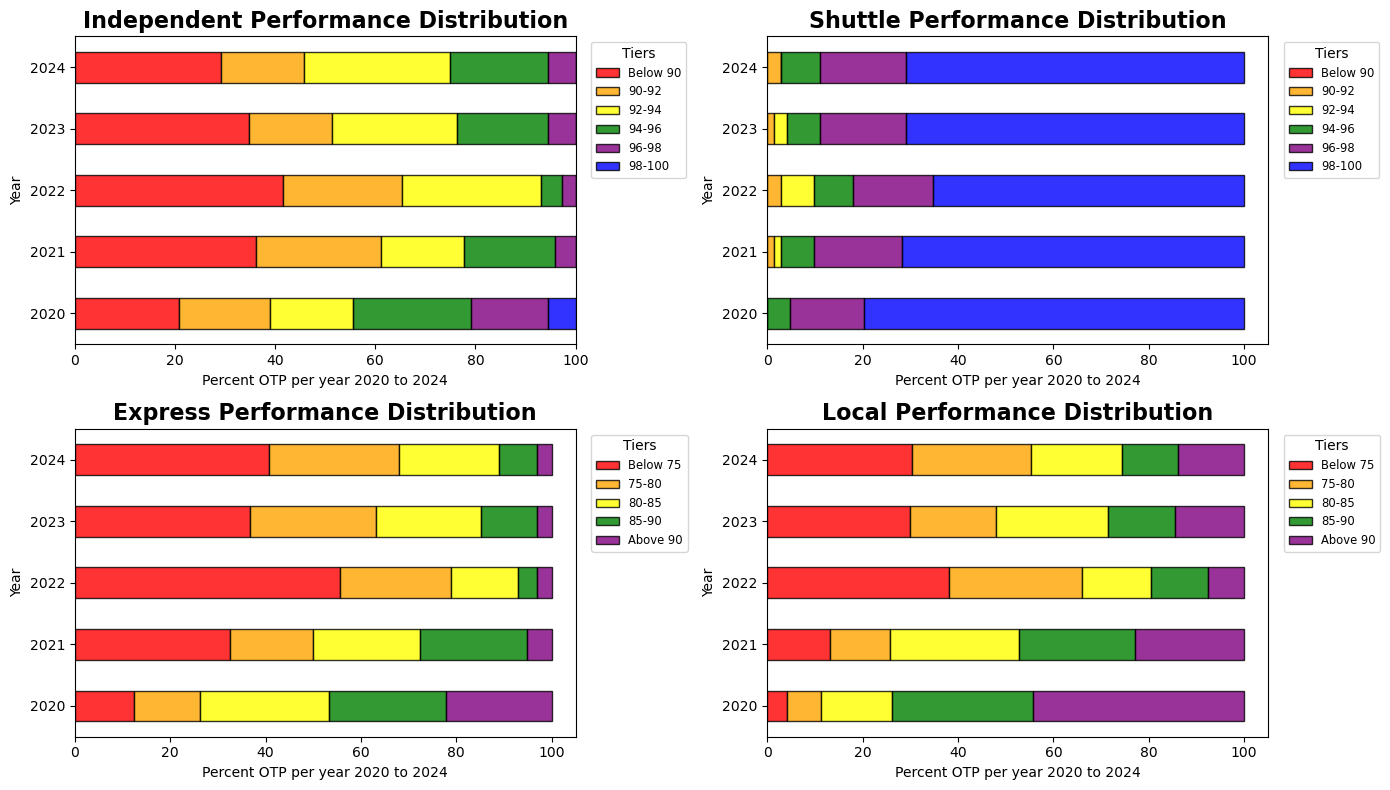

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

expresslines = ['2', '3', '4', '5', 'A', 'E', 'Q', 'B', 'D', 'N']
locallines = ['1', '6', '7', 'C', 'R', 'W', 'L', 'G', 'M', 'F','JZ']
shuttles = ['MS', 'BS', 'QS', 'FS', 'GS', 'H']
independentlines = ['7', 'L', 'G']

ontimeperformance = pd.read_csv('MTA_Subway_Terminal_On-Time_Performance__2020-2024_20260226.csv')

service_map = {}
for line in expresslines: service_map[line] = 'Express'
for line in locallines: service_map[line] = 'Local'
for line in shuttles: service_map[line] = 'Shuttle'
for line in independentlines: service_map[line] = 'Independent'

ontimeperformance['service_group'] = ontimeperformance['line'].map(service_map)
ontimeperformance['year_extracted'] = ontimeperformance['month'].astype(str).str[:4]

regularOTP_bins = [0, 75, 80, 85, 90, 101]
regularOTP_labels = ['Below 75', '75-80', '80-85', '85-90', 'Above 90']


highOTP_bins = [0, 90, 92, 94, 96, 98, 101]
highOTP_labels = ['Below 90', '90-92', '92-94', '94-96', '96-98', '98-100']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))
axes_flat = axes.flatten()
categories = ['Independent', 'Shuttle', 'Express', 'Local']
colors = ['Red', 'Orange', 'Yellow', 'Green', 'Purple', 'Blue']

for i, s_type in enumerate(categories):
    ax = axes_flat[i]
    df_filtered = ontimeperformance[ontimeperformance['service_group'] == s_type].copy()
    
    current_bins = highOTP_bins if s_type in ['Independent', 'Shuttle'] else regularOTP_bins
    current_labels = highOTP_labels if s_type in ['Independent', 'Shuttle'] else regularOTP_labels
    
    df_filtered['otp_tier'] = pd.cut(df_filtered['terminal_on_time_performance'], 
                                     bins=current_bins, labels=current_labels)
    
    pivot = df_filtered.groupby(['year_extracted', 'otp_tier'], observed=False).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    
    pivot_pct.plot(kind='barh', stacked=True, ax=ax, color=colors, edgecolor='black', alpha=0.8)
    
    ax.set_title(f'{s_type} Performance Distribution', fontsize=16, fontweight='bold')
    ax.set_xlabel('Percent OTP per year 2020 to 2024')
    ax.set_ylabel('Year')
    ax.legend(title="Tiers", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()




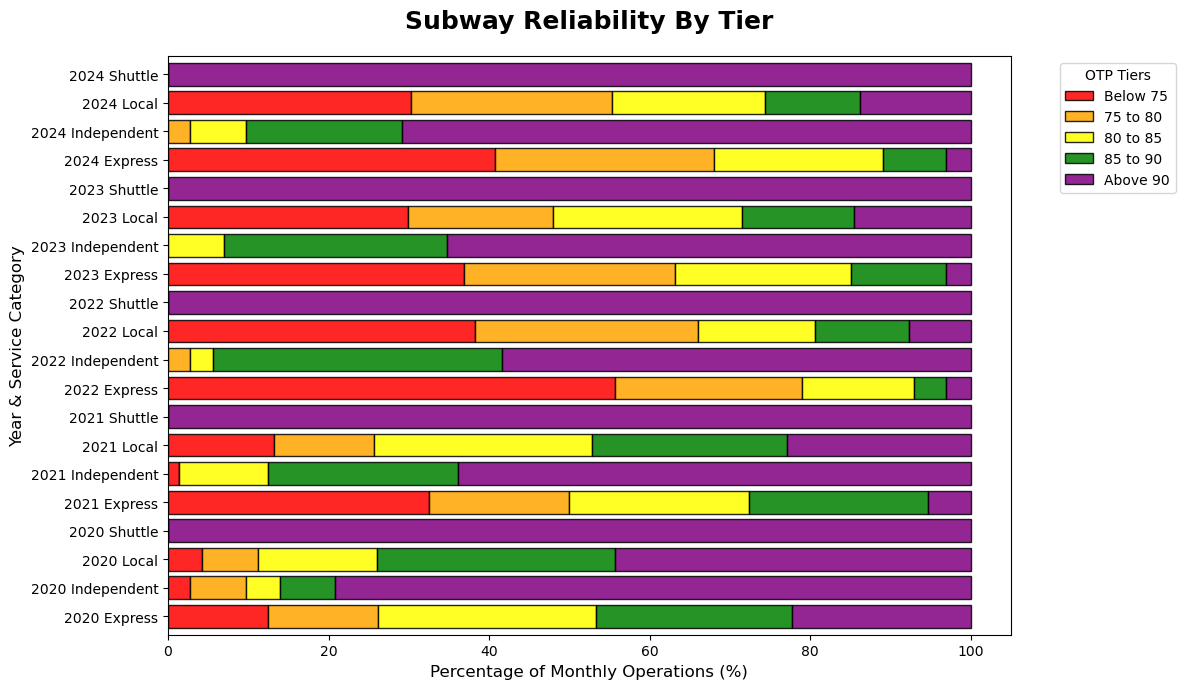

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
expresslines = ['2', '3', '4', '5', 'A', 'E', 'Q', 'B', 'D', 'N']
locallines = ['1', '6', '7', 'C', 'R', 'W', 'L', 'G', 'M', 'F','JZ']
shuttles = ['MS', 'BS', 'QS', 'FS', 'GS', 'H']
independentlines = ['7', 'L', 'G']
ontimeperformance = pd.read_csv('MTA_Subway_Terminal_On-Time_Performance__2020-2024_20260226.csv')
service_map = {}
for line in expresslines: service_map[line] = 'Express'
for line in locallines: service_map[line] = 'Local'
for line in shuttles: service_map[line] = 'Shuttle'
for line in independentlines: service_map[line] = 'Independent'

ontimeperformance['service_group'] = ontimeperformance['line'].map(service_map)

ontimeperformance['year_extracted'] = ontimeperformance['month'].astype(str).str[:4]

ontimeperformance['y_summary_label'] = (
    ontimeperformance['year_extracted'] + " " + 
    ontimeperformance['service_group'].astype(str)
)

bins = [0, 75, 80, 85, 90, 101]
labels = ['Below 75', '75 to 80', '80 to 85', '85 to 90', 'Above 90']
ontimeperformance['otp_tier'] = pd.cut(ontimeperformance['terminal_on_time_performance'], 
                                       bins=bins, labels=labels)

summary_pivot = ontimeperformance.groupby(['y_summary_label', 'otp_tier'], observed=False).size().unstack(fill_value=0)

summary_pivot = summary_pivot[~summary_pivot.index.str.contains('nan')]

summary_pct = summary_pivot.div(summary_pivot.sum(axis=1), axis=0) * 100

custom_colors = ['Red', 'Orange', 'Yellow', 'Green', 'Purple'] 

ax = summary_pct.plot(kind='barh', stacked=True, color=custom_colors, 
                      edgecolor='black', alpha=0.85, width=0.8, figsize=(12, 7))

plt.title('Subway Reliability By Tier', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Percentage of Monthly Operations (%)', fontsize=12)
plt.ylabel('Year & Service Category', fontsize=12)
plt.legend(title="OTP Tiers", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()